# Physics-Informed Neural Networks (PINNs) in Neuromancer

This tutorial demonstrates the use of [PINNs](https://en.wikipedia.org/wiki/Physics-informed_neural_networks) for solving partial differential equations (PDEs) in the Neuromancer library.


<img src="../figs/PINNs.png" width="600">  


### References

[1] [Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2017). Physics informed deep learning (part i): Data-driven solutions of nonlinear partial differential equations.](https://www.sciencedirect.com/science/article/abs/pii/S0021999118307125)

[2] https://github.com/jdtoscano94/Learning-Python-Physics-Informed-Machine-Learning-PINNs-DeepONets/tree/main

[3] https://github.com/omniscientoctopus/Physics-Informed-Neural-Networks/tree/main


## Install (Colab only)
Skip this step when running locally.

In [1]:
# !pip install neuromancer
# !pip install pyDOE

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

## Imports

In [ ]:
# torch and numpy imports
import torch
import torch.nn as nn
import numpy as np

# plotting imports
import matplotlib.pyplot as plt

# filter some user warnings from torch broadcast
import warnings

warnings.filterwarnings("ignore")


In [ ]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


## Problem Setup

original source: https://deepxde.readthedocs.io/en/latest/demos/pinn_forward/diffusion.1d.html

**Diffusion equation**

$$\frac{\partial y}{\partial t} =\frac{\partial^2 y}{\partial x^2}-e^{-t}(sin(\pi x)-\pi^2 sin(\pi x))$$

$$x\in[-1,1]$$
$$t\in[0,1]$$

**Initial Condition:**

$$y(x,0)=sin(\pi x)$$

**Boundary Conditions:**

$$y(-1,t)=0$$
$$y(1,t)=0$$

**Exact solution:**

$$y(x,t)=e^{-t}sin(\pi x)$$

### Generate data of the exact solution

In [ ]:
# exact solution y(x,t)
def f_real(x, t):
    return torch.exp(-t) * (torch.sin(np.pi * x))


# define range of the space and time variables:
x_min = -1
x_max = 1
t_min = 0
t_max = 1

# define number of spatial and temporal points
total_points_x = 200
total_points_t = 100

# generate samples of x, t
x = torch.linspace(x_min, x_max, total_points_x).view(-1, 1)
t = torch.linspace(t_min, t_max, total_points_t).view(-1, 1)

# Create the mesh of x, t
X, T = torch.meshgrid(x.squeeze(1), t.squeeze(1), indexing="ij")

# Evaluate exact solution y(x,t) on the mesh
y_real = f_real(X, T)

# data shapes
print(x.shape, t.shape)
print(X.shape, T.shape, y_real.shape)

torch.Size([200, 1]) torch.Size([100, 1])
torch.Size([200, 100]) torch.Size([200, 100]) torch.Size([200, 100])


In [5]:
# min and max values of the PDE solution
ymin = y_real.min()
ymax = y_real.max()
print(ymin, ymax)

tensor(-1.0000) tensor(1.0000)


### Plot the exact solution

In [ ]:
def plot3D(X, T, y):
    #     2D
    fig = plt.figure()
    ax1 = fig.add_subplot(121)
    cm = ax1.contourf(T.numpy(), X.numpy(), y.numpy(), 20, cmap="viridis")
    fig.colorbar(cm, ax=ax1)  # Add a colorbar to a plot
    ax1.set_title("y(x,t)")
    ax1.set_xlabel("t")
    ax1.set_ylabel("x")
    ax1.set_aspect("equal")
    #     3D
    ax2 = fig.add_subplot(122, projection="3d")
    ax2.plot_surface(T.numpy(), X.numpy(), y.numpy(), cmap="viridis")
    ax2.set_xlabel("t")
    ax2.set_ylabel("x")
    ax2.set_zlabel("y(x,t)")
    fig.tight_layout()

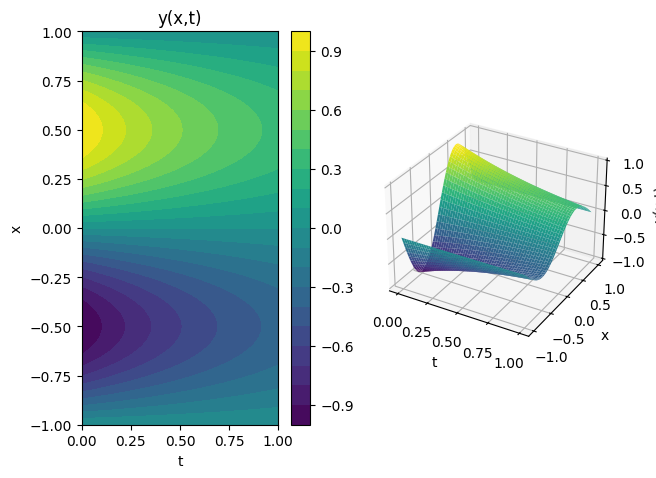

In [ ]:
plot3D(X, T, y_real)

### Test data: exact PDE solution

In [ ]:
# Transform the mesh into a 2-column vector
X_test = X.transpose(1, 0).flatten()[:, None].float()  # the input dataset of x
T_test = T.transpose(1, 0).flatten()[:, None].float()  # the input dataset of t
Y_test = (
    y_real.transpose(1, 0).flatten()[:, None].float()
)  # the real solution over (x,t)
print(X_test.shape, T_test.shape, Y_test.shape)

torch.Size([20000, 1]) torch.Size([20000, 1]) torch.Size([20000, 1])


##  Construct training datasets

We construct training and development datasets containing [collocation points (CP)](https://en.wikipedia.org/wiki/Collocation_method) of the spatio-temporal domain (x,t), and samples of the [initial conditions (IC)](https://en.wikipedia.org/wiki/Initial_condition), and [boundary conditions (BC)](https://en.wikipedia.org/wiki/Boundary_value_problem).

The dataset is given as:
$\Xi_{\text{train/dev}} = [\texttt{CP}^i, \texttt{IC}^j, \texttt{BC}^j]$, $i = 1,...,N_f$, $j = 1,...,N_u$  
Where $N_f$ defines number of collocation points, and $N_u$ number of initial and boundary condition samples.

### Samples of Initial Condition (IC)

In [ ]:
#   Left Edge: y(x,0) = sin(pi*x)
left_X = X[:, [0]]
left_T = T[:, [0]]
left_Y = torch.sin(np.pi * left_X[:, 0]).unsqueeze(1)
print(left_X.shape, left_T.shape, left_Y.shape)

torch.Size([200, 1]) torch.Size([200, 1]) torch.Size([200, 1])


### Samples of Boundary Conditions (BC)

In [10]:
#   Bottom Edge: x=min; tmin=<t=<max
bottom_X = X[[0], :].T
bottom_T = T[[0], :].T
bottom_Y = torch.zeros(bottom_X.shape[0], 1)
print(bottom_X.shape, bottom_T.shape, bottom_Y.shape)
#   Top Edge: x=max; 0=<t=<1
top_X = X[[-1], :].T
top_T = T[[-1], :].T
top_Y = torch.zeros(top_X.shape[0], 1)
print(top_X.shape, top_T.shape, top_Y.shape)

torch.Size([100, 1]) torch.Size([100, 1]) torch.Size([100, 1])
torch.Size([100, 1]) torch.Size([100, 1]) torch.Size([100, 1])


### Number of training samples for IC and BC

In [11]:
# Get all the initial and boundary condition data
X_train = torch.vstack([left_X, bottom_X, top_X])
T_train = torch.vstack([left_T, bottom_T, top_T])
Y_train = torch.vstack([left_Y, bottom_Y, top_Y])
print(X_train.shape, T_train.shape, Y_train.shape)

# Choose (Nu) Number of training points for initial and boundary conditions
Nu = 200

# Randomly sample Nu points of our available initial and boundary condition data:
idx = np.sort(np.random.choice(X_train.shape[0], Nu, replace=False))
X_train_Nu = X_train[idx, :].float()  # Training Points  of x at (IC+BC)
T_train_Nu = T_train[idx, :].float()  # Training Points  of t at (IC+BC)
Y_train_Nu = Y_train[idx, :].float()  # Training Points  of y at (IC+BC)
print(X_train_Nu.shape, T_train_Nu.shape, Y_train_Nu.shape)

torch.Size([400, 1]) torch.Size([400, 1]) torch.Size([400, 1])
torch.Size([200, 1]) torch.Size([200, 1]) torch.Size([200, 1])


### Samples of Collocation Points (CP)

In [ ]:
# x Domain bounds
x_lb = X_test[0]  # first value
x_ub = X_test[-1]  # last value
print(x_lb, x_ub)

# t Domain bounds
t_lb = T_test[0]  # first value
t_ub = T_test[-1]  # last value
print(t_lb, t_ub)

#  Choose (Nf) Collocation Points to Evaluate the PDE on
Nf = 1000  # Nf: Number of collocation points (Evaluate PDE)

# generate collocation points (CP)
X_train_CP = torch.FloatTensor(Nf, 1).uniform_(float(x_lb), float(x_ub))
T_train_CP = torch.FloatTensor(Nf, 1).uniform_(float(t_lb), float(t_ub))
print(X_train_CP.shape, T_train_CP.shape)

# add IC+BC to the collocation points
X_train_Nf = torch.vstack(
    (X_train_CP, X_train_Nu)
).float()  # Collocation Points of x (CP)
T_train_Nf = torch.vstack(
    (T_train_CP, T_train_Nu)
).float()  # Collocation Points of t (CP)
print(X_train_Nf.shape, T_train_Nf.shape)

tensor([-1.]) tensor([1.])
tensor([0.]) tensor([1.])
torch.Size([1000, 1]) torch.Size([1000, 1])
torch.Size([1200, 1]) torch.Size([1200, 1])


In [ ]:
print("Original shapes for X, T, and Y:", X.shape, T.shape, y_real.shape)
print(
    "Initial and Boundary condition shapes for X:",
    left_X.shape,
    bottom_X.shape,
    top_X.shape,
)
print(
    "Initial and Boundary condition shapes for T:",
    left_T.shape,
    bottom_T.shape,
    top_T.shape,
)
print(
    "Available training data of IC and BC (X,T,Y):",
    X_train.shape,
    T_train.shape,
    Y_train.shape,
)
print(
    "Selected training data of IC and BC (X,T,Y):",
    X_train_Nu.shape,
    T_train_Nu.shape,
    Y_train_Nu.shape,
)
print("Final training data of CP (X,T):", X_train_Nf.shape, T_train_Nf.shape)
print("Final test data (X,T,Y):", X_test.shape, T_test.shape, Y_test.shape)

Original shapes for X, T, and Y: torch.Size([200, 100]) torch.Size([200, 100]) torch.Size([200, 100])
Initial and Boundary condition shapes for X: torch.Size([200, 1]) torch.Size([100, 1]) torch.Size([100, 1])
Initial and Boundary condition shapes for T: torch.Size([200, 1]) torch.Size([100, 1]) torch.Size([100, 1])
Available training data of IC and BC (X,T,Y): torch.Size([400, 1]) torch.Size([400, 1]) torch.Size([400, 1])
Selected training data of IC and BC (X,T,Y): torch.Size([200, 1]) torch.Size([200, 1]) torch.Size([200, 1])
Final training data of CP (X,T): torch.Size([1200, 1]) torch.Size([1200, 1])
Final test data (X,T,Y): torch.Size([20000, 1]) torch.Size([20000, 1]) torch.Size([20000, 1])


### Plot collocation points

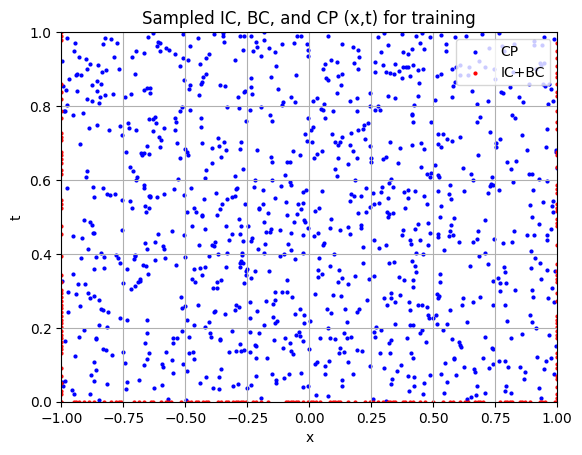

In [ ]:
# visualize collocation points for 2D input space (x, t)
plt.figure()
plt.scatter(
    X_train_CP.detach().numpy(),
    T_train_CP.detach().numpy(),
    s=4.0,
    c="blue",
    marker="o",
    label="CP",
)
plt.scatter(
    X_train_Nu.detach().numpy(),
    T_train_Nu.detach().numpy(),
    s=4.0,
    c="red",
    marker="o",
    label="IC+BC",
)
plt.title("Sampled IC, BC, and CP (x,t) for training")
plt.xlim(x_lb, x_ub)
plt.ylim(t_lb, t_ub)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("t")
plt.legend(loc="upper right")
plt.show()
plt.show(block=True)

Insert training dataset for FNO, which is a sub-sampled 32x32 grid from the original 200X100 data

In [ ]:
def make_fno_grid(nx, nt, requires_grad=False):
    x = torch.linspace(x_min, x_max, nx)
    t = torch.linspace(t_min, t_max, nt)
    X, T = torch.meshgrid(x, t, indexing="ij")
    Y = f_real(X, T)
    # flatten to column vectors (Node expects {'x': [N,1], ...})
    # X_vec = X.transpose(1, 0).flatten()[:, None].float()
    # T_vec = T.transpose(1, 0).flatten()[:, None].float()
    # Y_vec = Y.transpose(1, 0).flatten()[:, None].float()
    xt_grid = torch.stack([X, T], dim=0).unsqueeze(0).float()  # [1, 2, nx, nt]
    y_grid = Y.unsqueeze(0).unsqueeze(0).float()
    # gra
    if requires_grad:
        xt_grid.requires_grad_(True)
    return xt_grid, y_grid


# 16x16 training grid
XT_train_grid, Y_train_grid = make_fno_grid(16, 16, requires_grad=True)
# 32x32 testing grid
XT_test_grid, Y_test_grid = make_fno_grid(32, 32, requires_grad=False)

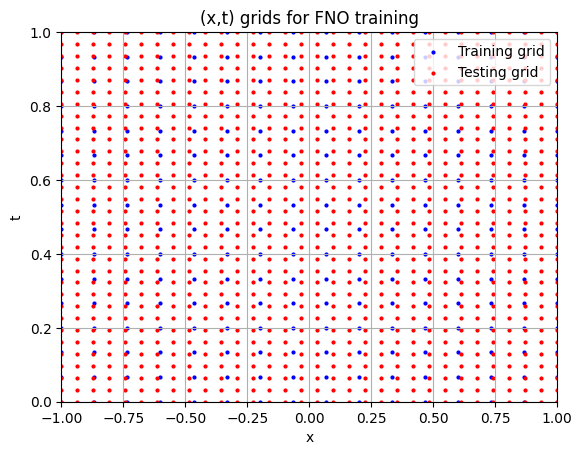

In [ ]:
# visualize collocation points for 2D input space (x, t)

# --- Prepare Training Data ---
# Select the x and t coordinates (indices 0 and 1 in dim 1)
# and flatten the last two dimensions (nx * nt) into one vector.
# .squeeze() removes the batch dimension (size 1).
X_train_flat = XT_train_grid.squeeze(0)[0, :, :].flatten()
T_train_flat = XT_train_grid.squeeze(0)[1, :, :].flatten()

# --- Prepare Testing Data (assuming a similar structure) ---
X_test_flat = XT_test_grid.squeeze(0)[0, :, :].flatten()
T_test_flat = XT_test_grid.squeeze(0)[1, :, :].flatten()

# --- Plotting ---
plt.figure()
plt.scatter(
    X_train_flat.detach().numpy(),
    T_train_flat.detach().numpy(),
    s=4.0,
    c="blue",
    marker="o",
    label="Training grid",
)
plt.scatter(
    X_test_flat.detach().numpy(),
    T_test_flat.detach().numpy(),
    s=4.0,
    c="red",
    marker="o",
    label="Testing grid",
)

plt.title("(x,t) grids for FNO training")
# Assuming x_lb, x_ub, t_lb, t_ub are defined in your environment
plt.xlim(x_lb, x_ub)
plt.ylim(t_lb, t_ub)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("t")
plt.legend(loc="upper right")
plt.show()
# plt.show(block=True) # Usually only one plt.show() is needed
plt.show(block=True)

### Create Neuromancer datasets for PINNs

In [ ]:
from neuromancer.dataset import DictDataset

# turn on gradients for PINN
X_train_Nf.requires_grad = True
T_train_Nf.requires_grad = True

# Training dataset
train_data = DictDataset({"x": X_train_Nf, "t": T_train_Nf}, name="train")
# test dataset
test_data = DictDataset({"x": X_test, "t": T_test, "y": Y_test}, name="test")

# torch dataloaders
batch_size = X_train_Nf.shape[0]  # full batch training
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=batch_size, collate_fn=train_data.collate_fn, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=batch_size, collate_fn=test_data.collate_fn, shuffle=False
)

### Create Neuromancer datasets for FNO

In [ ]:
# turn on gradients for FNO
XT_train_grid = XT_train_grid.to(device)
Y_train_grid = Y_train_grid.to(device)

# Prepare FNO training and testing datasets
train_ds_fno = DictDataset(
    {"xt_grid": XT_train_grid, "y_grid": Y_train_grid}, name="fno_train"
)
train_loader_fno = torch.utils.data.DataLoader(
    train_ds_fno, batch_size=1, collate_fn=train_ds_fno.collate_fn, shuffle=False
)

# testing grid
test_ds_fno = DictDataset(
    {"xt_grid": XT_test_grid, "y_grid": Y_test_grid}, name="fno_test"
)
test_loader_fno = torch.utils.data.DataLoader(
    test_ds_fno, batch_size=1, collate_fn=test_ds_fno.collate_fn, shuffle=False
)

## PINN Architecture in Neuromancer

### Neural Network Architecture

We will use a neural network to approximate the PDE solution:
$$\hat{y} = NN_{\theta}(x,t)$$  

In [ ]:
from neuromancer.modules import blocks
from neuromancer.system import Node

# neural net to solve the PDE problem bounded in the PDE domain
net = blocks.MLP(insize=2, outsize=1, hsizes=[32, 32], nonlin=nn.Tanh)

# symbolic wrapper of the neural net
pde_net = Node(net, ["x", "t"], ["y_hat"], name="net")

In [20]:
print("symbolic inputs  of the pde_net:", pde_net.input_keys)
print("symbolic outputs of the pde_net:", pde_net.output_keys)

symbolic inputs  of the pde_net: ['x', 't']
symbolic outputs of the pde_net: ['y_hat']


In [ ]:
# evaluate forward pass on the train data
net_out = pde_net(train_data.datadict)
net_out["y_hat"].shape

torch.Size([1200, 1])

### FNO added from neuralop library
May need a wrapper to provide data in the correct format


In [ ]:
from neuralop.models import FNO
from neuralop.utils import count_model_params
import sys

fno_model = FNO(
    n_modes=(8, 8),
    in_channels=2,
    out_channels=1,
    hidden_channels=12,
    projection_channel_ratio=2,
)
fno_model = fno_model.to(device)

# Count and display the number of parameters
n_params = count_model_params(fno_model)
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush()


Our model has 48157 parameters.


In [ ]:
# symbolic wrapper of the FNO
fno_node = Node(fno_model, ["xt_grid"], ["y_hat_fno"], name="fno_model")

In [24]:
print("symbolic inputs  of the fno_node:", fno_node.input_keys)
print("symbolic outputs of the fno_node:", fno_node.output_keys)

symbolic inputs  of the fno_node: ['xt_grid']
symbolic outputs of the fno_node: ['y_hat_fno']


In [26]:
print(device)

cuda


In [ ]:
# evaluate forward pass on the train data
fno_model_out = fno_node(train_ds_fno.datadict)
fno_model_out["y_hat_fno"].shape

RuntimeError: Expected all tensors to be on the same device, but got tensors is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_cat)

###  Define Physics-informed terms of the PINN

Our neural network approximation  must satisfy the PDE equations  $NN_{\theta}(x,t) \approx y(x,t)$. 
Thus we define the physics-informed layers as $f_{\texttt{PINN}}$:

$$f_{\texttt{PINN}}(t,x)=\left(\frac{\partial NN_{\theta}}{\partial t} -\frac{\partial^2 NN_{\theta}}{\partial x^2}
\right)+e^{-t}(sin(\pi x)-\pi^2 sin(\pi x)) $$

We can obtain the derivatives of the neural net $\frac{\partial NN_{\theta}}{\partial t},\frac{\partial^2 NN_{\theta}}{\partial x^2}$ using [Automatic Diferentiation](https://en.wikipedia.org/wiki/Automatic_differentiation). 

To simplify the implementation of $f_{\texttt{PINN}}$ we exploit the symbolic variable of the Neuromancer library. 

In [ ]:
from neuromancer.constraint import variable

# symbolic Neuromancer variables
y_hat = variable(
    "y_hat"
)  # PDE solution generated as the output of a neural net (pde_net)
t = variable("t")  # temporal domain
x = variable("x")  # spatial domain

In [ ]:
# get the symbolic derivatives
dy_dt = y_hat.grad(t)
dy_dx = y_hat.grad(x)
d2y_d2x = dy_dx.grad(x)
# get the PINN form
f_pinn = (
    dy_dt
    - d2y_d2x
    + torch.exp(-t) * (torch.sin(torch.pi * x) - torch.pi**2 * torch.sin(torch.pi * x))
)

In [20]:
# check the shapes of the forward pass of the symbolic PINN terms
print(dy_dt({**net_out, **train_data.datadict}).shape)
print(dy_dx({**net_out, **train_data.datadict}).shape)
print(d2y_d2x({**net_out, **train_data.datadict}).shape)
print(f_pinn({**net_out, **train_data.datadict}).shape)

torch.Size([1200, 1])
torch.Size([1200, 1])
torch.Size([1200, 1])
torch.Size([1200, 1])


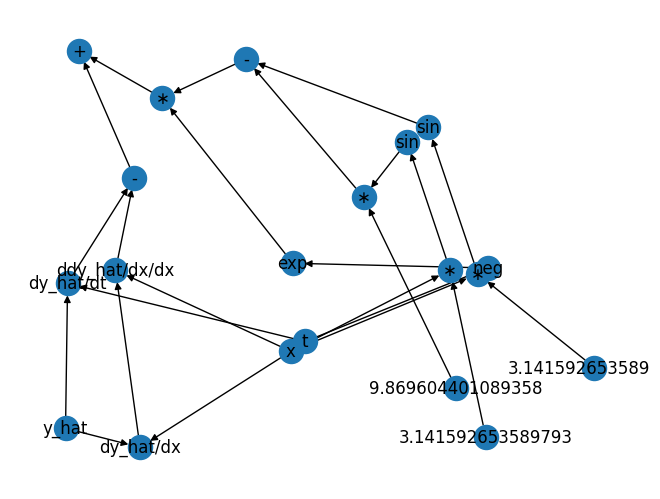

In [21]:
# computational graph of the PINN neural network
f_pinn.show()

### PINNs' Loss function terms

**PDE Collocation Points Loss:**  
We evaluate our PINN $f_{\texttt{PINN}}$ over given number ($N_f$) of collocation points (CP) and minimize the PDE residuals in the following loss function:

$$\ell_{f}=\frac{1}{N_f}\sum^{N_f}_{i=1}|f_{\texttt{PINN}}(t_f^i,x_f^i)|^2$$


If $f_{\texttt{PINN}}\rightarrow 0$ then our PINN will be respecting the physical law.

**PDE Initial and Boundary Conditions Loss:**

We select $N_u$ points from our BC and IC and used them in the following supervised learning loss function:

$$\ell_{u}=\frac{1}{N_u}\sum^{N_u}_{i=1}|y(t_{u}^i,x_u^i)-NN_{\theta}(t_{u}^i,x_u^i)|^2$$

**Bound the PINN output in the PDE solution domain:**  
We expect the outputs of the neural net to be bounded in the PDE solution domain $NN_{\theta}(x,t) \in [-1.0, 1.0]$, thus we impose the following inequality constraints via additional penalties:

$$\ell_{y}=\frac{1}{N_f}\sum^{N_f}_{i=1} \Big(|\texttt{RELU}(NN_{\theta}(t_{f}^i,x_f^i) - y_{max})|^2 + |\texttt{RELU}(-NN_{\theta}(t_{f}^i,x_f^i) + y_{min})|^2 \Big)$$


#### Total Loss:
The total loss is just a sum of PDE residuals over CP and supervised learning residuals over IC and BC.
$$\ell_{\text{PINN}}=\ell_{f}+\ell_{u} +\ell_{y}$$

In [ ]:
# scaling factor for better convergence
scaling = 100.0

# PDE CP loss
ell_f = scaling * (f_pinn == 0.0) ^ 2

# PDE IC and BC loss
ell_u = (
    scaling * (y_hat[-Nu:] == Y_train_Nu) ^ 2
)  # remember we stacked CP with IC and BC

# output constraints to bound the PINN solution in the PDE output domain [-1.0, 1.0]
con_1 = scaling * (y_hat <= ymax) ^ 2
con_2 = scaling * (y_hat >= ymin) ^ 2

##  Train the PINN to solve the PDE

We use stochastic gradient descent to optimize the parameters $\theta$ of the neural network $NN_{\theta}(t,x)$ approximating the solution to the PDE equation $y(t,x)$ using the PINN loss $\ell_{\text{PINN}}$ evaluated over sampled CP, IP, and BC.

### Define the optimization problem in Neuromancer

In [ ]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

# create Neuromancer optimization loss
pinn_loss = PenaltyLoss(objectives=[ell_f, ell_u], constraints=[con_1, con_2])

# construct the PINN optimization problem
problem = Problem(
    nodes=[pde_net],  # list of nodes (neural nets) to be optimized
    loss=pinn_loss,  # physics-informed loss function
    grad_inference=True,  # argument for allowing computation of gradients at the inference time)
)

# Visualize the problem graph. Note: must have graphviz installed in the system
# problem.show()

### Construct Trainer and solve the problem  

In [ ]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)
epochs = 5000

#  Neuromancer trainer
trainer = Trainer(
    problem.to(device),
    train_loader,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=200,
    train_metric="train_loss",
    dev_metric="train_loss",
    eval_metric="train_loss",
    warmup=epochs,
    device=device,
)

In [25]:
# Train PINN
best_model = trainer.train()

# load best trained model
problem.load_state_dict(best_model)

epoch: 0  train_loss: 1760.5653076171875
epoch: 200  train_loss: 9.44287109375
epoch: 400  train_loss: 1.7678852081298828
epoch: 600  train_loss: 0.9978035688400269
epoch: 800  train_loss: 0.5323358178138733
epoch: 1000  train_loss: 0.31976449489593506
epoch: 1200  train_loss: 0.21733325719833374
epoch: 1400  train_loss: 0.15941959619522095
epoch: 1600  train_loss: 0.12006612122058868
epoch: 1800  train_loss: 0.09137120842933655
epoch: 2000  train_loss: 0.0708281397819519
epoch: 2200  train_loss: 0.0525147020816803
epoch: 2400  train_loss: 0.0429733507335186
epoch: 2600  train_loss: 0.030613970011472702
epoch: 2800  train_loss: 0.025473475456237793
epoch: 3000  train_loss: 0.019273128360509872
epoch: 3200  train_loss: 0.01856963522732258
epoch: 3400  train_loss: 0.016935087740421295
epoch: 3600  train_loss: 0.042569778859615326
epoch: 3800  train_loss: 0.01148306392133236
epoch: 4000  train_loss: 0.008972265757620335
epoch: 4200  train_loss: 0.009409179911017418
epoch: 4400  train_loss

<All keys matched successfully>

## Plots

In [ ]:
# evaluate trained PINN on test data
PINN = problem.nodes[0].cpu()
y1 = PINN(test_data.datadict)["y_hat"]

# arrange data for plotting
y_pinn = y1.reshape(shape=[100, 200]).transpose(1, 0).detach().cpu()

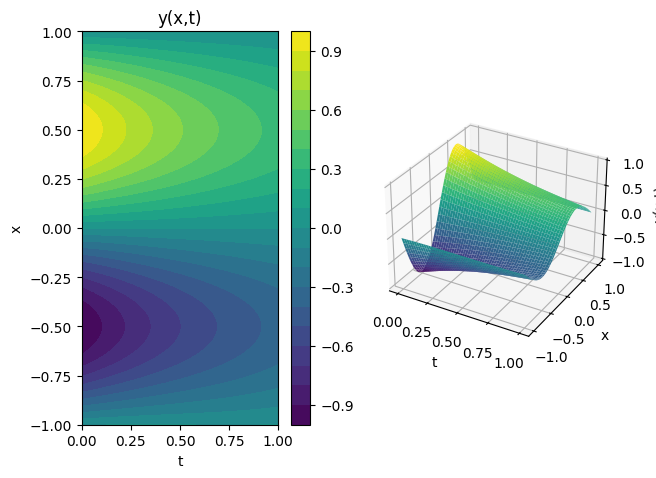

In [27]:
# plot PINN solution
plot3D(X, T, y_pinn)

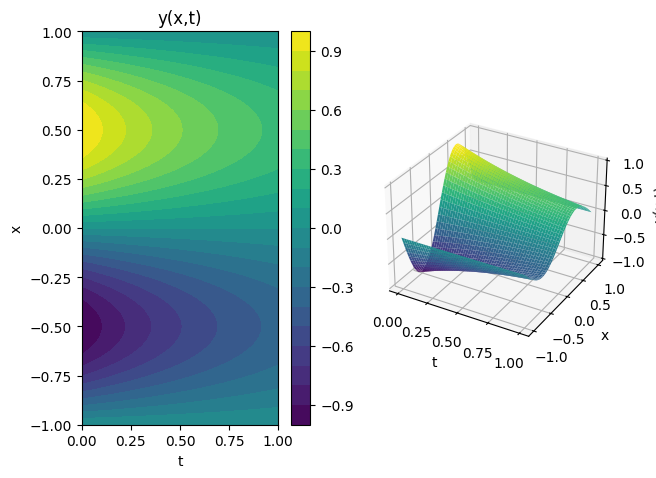

In [28]:
# plot exact PDE solution
plot3D(X, T, y_real)

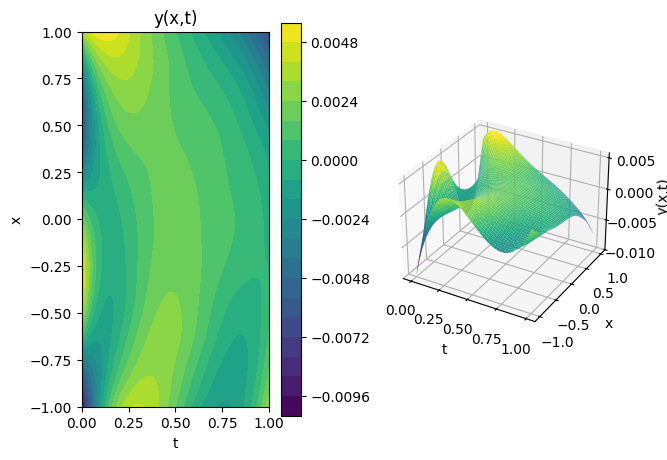

In [ ]:
# plot residuals PINN - exact PDE
plot3D(X, T, y_pinn - y_real)